In [ ]:
import os
import gdown
import zipfile
import numpy as np
import random

import yaml
import ultralytics
from ultralytics import YOLO
import cv2
import globox as gx

import matplotlib.pyplot as plt

import opendatasets as od

WARNING  Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\kumar\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


We can delete this cell later

In [ ]:
# Download NEU-DET from Kaggle

od.download("https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database", data_dir="data/")

In [ ]:
# Globox for annotation conversion

ann_path = r"A:\Data Science\Yolo_over_Cv\data\neu-surface-defect-database\NEU-DET\train\annotations"
output_path = r"A:\Data Science\Yolo_over_Cv\data\neu-surface-defect-database\NEU-DET\train\labels"

os.makedirs(output_path, exist_ok=True)

# Define class mapping
class_map = {
    'crazing': 0,
    'inclusion': 1,
    'patches': 2,
    'pitted_surface': 3,
    'rolled-in_scale': 4,
    'scratches': 5
}

# VOC annotations
annotations = gx.AnnotationSet.from_pascal_voc(folder=ann_path)
annotations.show_stats()

# Convert to YOLO
annotations.save_yolo_v5(
    save_dir=output_path,
    label_to_id=class_map
)

print("Conversion complete")
print("Files in output folder:", os.listdir(output_path)[:10])

Installing globox...
Loading VOC annotations...
Showing dataset stats...


           Database Stats           
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Label           ┃ Images ┃ Boxes ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ crazing         │    239 │   524 │
│ inclusion       │    311 │   852 │
│ patches         │    269 │   688 │
│ pitted_surface  │    241 │   345 │
│ rolled-in_scale │    240 │   496 │
│ scratches       │    240 │   427 │
├─────────────────┼────────┼───────┤
│ Total           │   1439 │  3332 │
└─────────────────┴────────┴───────┘

Converting to YOLO format...
Conversion complete
Files in output folder: ['crazing_1.txt', 'crazing_10.txt', 'crazing_100.txt', 'crazing_101.txt', 'crazing_102.txt', 'crazing_103.txt', 'crazing_104.txt', 'crazing_105.txt', 'crazing_106.txt', 'crazing_107.txt']


In [13]:
# Cell 13: Check a few converted files
import os

output_path = r"A:\Data Science\Yolo_over_Cv\data\neu-surface-defect-database\NEU-DET\train\labels"

txt_files = [f for f in os.listdir(output_path) if f.endswith('.txt')][:3]

for txt_file in txt_files:
    file_path = os.path.join(output_path, txt_file)
    print(f"\n{txt_file}:")
    with open(file_path, 'r') as f:
        content = f.read().strip()
        # print(content)
        line_count = len(content.split('\n'))
        print(f"Number of defects in this image: {line_count}")


crazing_1.txt:
Number of defects in this image: 1

crazing_10.txt:
Number of defects in this image: 2

crazing_100.txt:
Number of defects in this image: 4


In [ ]:
# Convert validation set annotations

val_ann_path = r"A:\Data Science\Yolo_over_Cv\data\neu-surface-defect-database\NEU-DET\validation\annotations"
val_output_path = r"A:\Data Science\Yolo_over_Cv\data\neu-surface-defect-database\NEU-DET\validation\labels"

os.makedirs(val_output_path, exist_ok=True)

class_map = {
    'crazing': 0,
    'inclusion': 1,
    'patches': 2,
    'pitted_surface': 3,
    'rolled-in_scale': 4,
    'scratches': 5
}

annotations = gx.AnnotationSet.from_pascal_voc(folder=val_ann_path)
annotations.show_stats()
# Convert to YOLO
annotations.save_yolo_v5(
    save_dir=val_output_path,
    label_to_id=class_map
)

print("Conversion complete")
print("Files in validation labels folder:", os.listdir(val_output_path)[:10])

Loading validation VOC annotations...
Validation set stats:


           Database Stats           
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Label           ┃ Images ┃ Boxes ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ crazing         │     61 │   165 │
│ inclusion       │     71 │   159 │
│ patches         │     73 │   193 │
│ pitted_surface  │     60 │    87 │
│ rolled-in_scale │     60 │   132 │
│ scratches       │     60 │   121 │
├─────────────────┼────────┼───────┤
│ Total           │    361 │   857 │
└─────────────────┴────────┴───────┘

Converting validation to YOLO format...
Conversion complete
Files in validation labels folder: ['crazing_240.txt', 'crazing_241.txt', 'crazing_242.txt', 'crazing_243.txt', 'crazing_244.txt', 'crazing_245.txt', 'crazing_246.txt', 'crazing_247.txt', 'crazing_248.txt', 'crazing_249.txt']


In [ ]:
# Model Training

train_path = r"A:\Data Science\Yolo_over_Cv\data\yolo_format\train\images"
val_path = r"A:\Data Science\Yolo_over_Cv\data\yolo_format\val\images"

class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# Create data dictionary
data = {
    'path': r"A:\Data Science\Yolo_over_Cv\data\yolo_format",  # base path
    'train': 'train/images',  
    'val': 'val/images',      
    'nc': len(class_names),
    'names': class_names
}

# Save as yaml file
yaml_path = r"A:\Data Science\Yolo_over_Cv\data\yolo_format\data_fixed_2.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("Fixed data.yaml created at:", yaml_path)
print("\nContent:")
with open(yaml_path, 'r') as f:
    print(f.read())

# Load model
model = YOLO('yolo11n.pt') # nano model

# Training
print("\nStarting training with fixed config")
results = model.train(
    data=yaml_path,
    epochs=80,
    imgsz=200,
    batch=16,
    name='defect_detection_fixed_2',
    device='cpu',
    workers=4,
    patience=15  
)

print("Training complete!")

Fixed data.yaml created at: A:\Data Science\Yolo_over_Cv\data\yolo_format\data_fixed_2.yaml

Content:
names:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches
nc: 6
path: A:\Data Science\Yolo_over_Cv\data\yolo_format
train: train/images
val: val/images


Starting training with fixed config...
New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.40  Python-3.11.9 torch-2.5.1+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=A:\Data Science\Yolo_over_Cv\data\yolo_format\data_fixed_2.yaml, epochs=80, time=None, patience=15, batch=16, imgsz=200, save=True, save_period=-1, cache=False, device=cpu, workers=4, project=None, name=defect_detection_fixed_2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0,

train: Scanning A:\Data Science\Yolo_over_Cv\data\yolo_format\train\labels.cache... 1439 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

train: WARNING  A:\Data Science\Yolo_over_Cv\data\yolo_format\train\images\crazing_120.jpg: 1 duplicate labels removed
train: WARNING  A:\Data Science\Yolo_over_Cv\data\yolo_format\train\images\inclusion_62.jpg: 1 duplicate labels removed
train: WARNING  A:\Data Science\Yolo_over_Cv\data\yolo_format\train\images\patches_198.jpg: 1 duplicate labels removed



val: Scanning A:\Data Science\Yolo_over_Cv\data\yolo_format\val\labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100%|██████████| 360/360 [00:00<?, ?it/s]

Plotting labels to runs\detect\defect_detection_fixed_2\labels.jpg... 


...

      80/80         0G      1.203      1.037      1.252         38        224: 100%|██████████| 90/90 [00:46<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:05<00:00,  2.07it/s]

                   all        360        854      0.667      0.655      0.718      0.385



80 epochs completed in 8.214 hours.
Optimizer stripped from runs\detect\defect_detection_fixed_2\weights\last.pt, 5.4MB
Optimizer stripped from runs\detect\defect_detection_fixed_2\weights\best.pt, 5.4MB

Validating runs\detect\defect_detection_fixed_2\weights\best.pt...
Ultralytics 8.3.40  Python-3.11.9 torch-2.5.1+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
YOLO11n summary (fused): 238 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:05<00:00,  2.21it/s]


                   all        360        854      0.669      0.655      0.718      0.385
               crazing         60        162      0.744      0.235      0.473      0.193
             inclusion         71        159      0.734      0.792      0.844      0.476
               patches         73        193      0.827      0.907      0.928      0.591
        pitted_surface         60         87      0.729      0.712      0.799      0.464
       rolled-in_scale         60        132      0.449      0.409      0.473      0.189
             scratches         60        121      0.529      0.876       0.79      0.396
Speed: 0.3ms preprocess, 10.8ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs\detect\defect_detection_fixed_2
Training complete!


In [14]:
# Results and Metrics 
# model
model = YOLO('runs/detect/defect_detection_fixed_2/weights/best.pt')

data_yaml = r"A:\Data Science\Yolo_over_Cv\data\yolo_format\data_fixed_2.yaml"
class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# Run validation
metrics = model.val(data=data_yaml, plots=True, save_json=True, verbose=False)

print("VALIDATION RESULTS")

print("\nBasic Information")
print("-"*70)
print(f"Task Type          : detect")
print(f"Model Name         : yolov11n")
print(f"Image Size         : 200")

# Overall accuracy
print("\nModel Accuracy")
print(f"Overall mAP50: {metrics.box.map50:.1%}")

# Find best and worst class
best_idx = metrics.box.ap50.argmax()
worst_idx = metrics.box.ap50.argmin()
print(f"\nBest class : {class_names[best_idx]} ({metrics.box.ap50[best_idx]:.1%})")
print(f"Worst class: {class_names[worst_idx]} ({metrics.box.ap50[worst_idx]:.1%})")

# Metrics
print("\nOverall Metrics")
print(f"mAP50              : {metrics.box.map50:.3f} ({metrics.box.map50:.1%})")
print(f"mAP50-95           : {metrics.box.map:.3f} ({metrics.box.map:.1%})")
print(f"Precision          : {metrics.box.mp:.3f} ({metrics.box.mp:.1%})")
print(f"Recall             : {metrics.box.mr:.3f} ({metrics.box.mr:.1%})")
f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr + 1e-10)
print(f"F1 Score           : {f1:.3f} ({f1:.1%})")

# Per-class accuracy and metrics
print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    print(f"  {name:15} : {metrics.box.ap50[i]:.1%}")

print("\nPer-Class Metrics")
print("-"*70)
print(f"{'Class':15} {'Precision':10} {'Recall':8} {'mAP50':8} {'mAP50-95':8}")
print("-"*70)

for i, name in enumerate(class_names):
    print(f"{name:15} {metrics.box.p[i]:.3f}     {metrics.box.r[i]:.3f}    "
          f"{metrics.box.ap50[i]:.3f}   {metrics.box.ap[i]:.3f}")

print("="*70)

Ultralytics 8.3.40  Python-3.11.9 torch-2.5.1+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
YOLO11n summary (fused): 238 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning A:\Data Science\Yolo_over_Cv\data\yolo_format\val\labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100%|██████████| 360/360 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:07<00:00,  3.13it/s]


                   all        360        854      0.669      0.655      0.718      0.385
Speed: 0.2ms preprocess, 12.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving runs\detect\val\predictions.json...
Results saved to runs\detect\val
VALIDATION RESULTS

Basic Information
----------------------------------------------------------------------
Task Type          : detect
Model Name         : yolov11n
Image Size         : 200

Model Accuracy
Overall mAP50: 71.8%

Best class : patches (92.8%)
Worst class: crazing (47.3%)

Overall Metrics
mAP50              : 0.718 (71.8%)
mAP50-95           : 0.385 (38.5%)
Precision          : 0.669 (66.9%)
Recall             : 0.655 (65.5%)
F1 Score           : 0.662 (66.2%)

Per-Class Accuracy:
  crazing         : 47.3%
  inclusion       : 84.4%
  patches         : 92.8%
  pitted_surface  : 79.9%
  rolled-in_scale : 47.3%
  scratches       : 79.0%

Per-Class Metrics
----------------------------------------------------------------------
Class

In [ ]:
# Save final model
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Best model
model = YOLO('runs/detect/defect_detection_fixed_2/weights/best.pt')

model.save('steel_defect_detector_2.pt')
print("Model saved as: steel_defect_detector_2.pt")

Model saved as: steel_defect_detector_2.pt


**Interactive dashboard by DASH using Plotly**

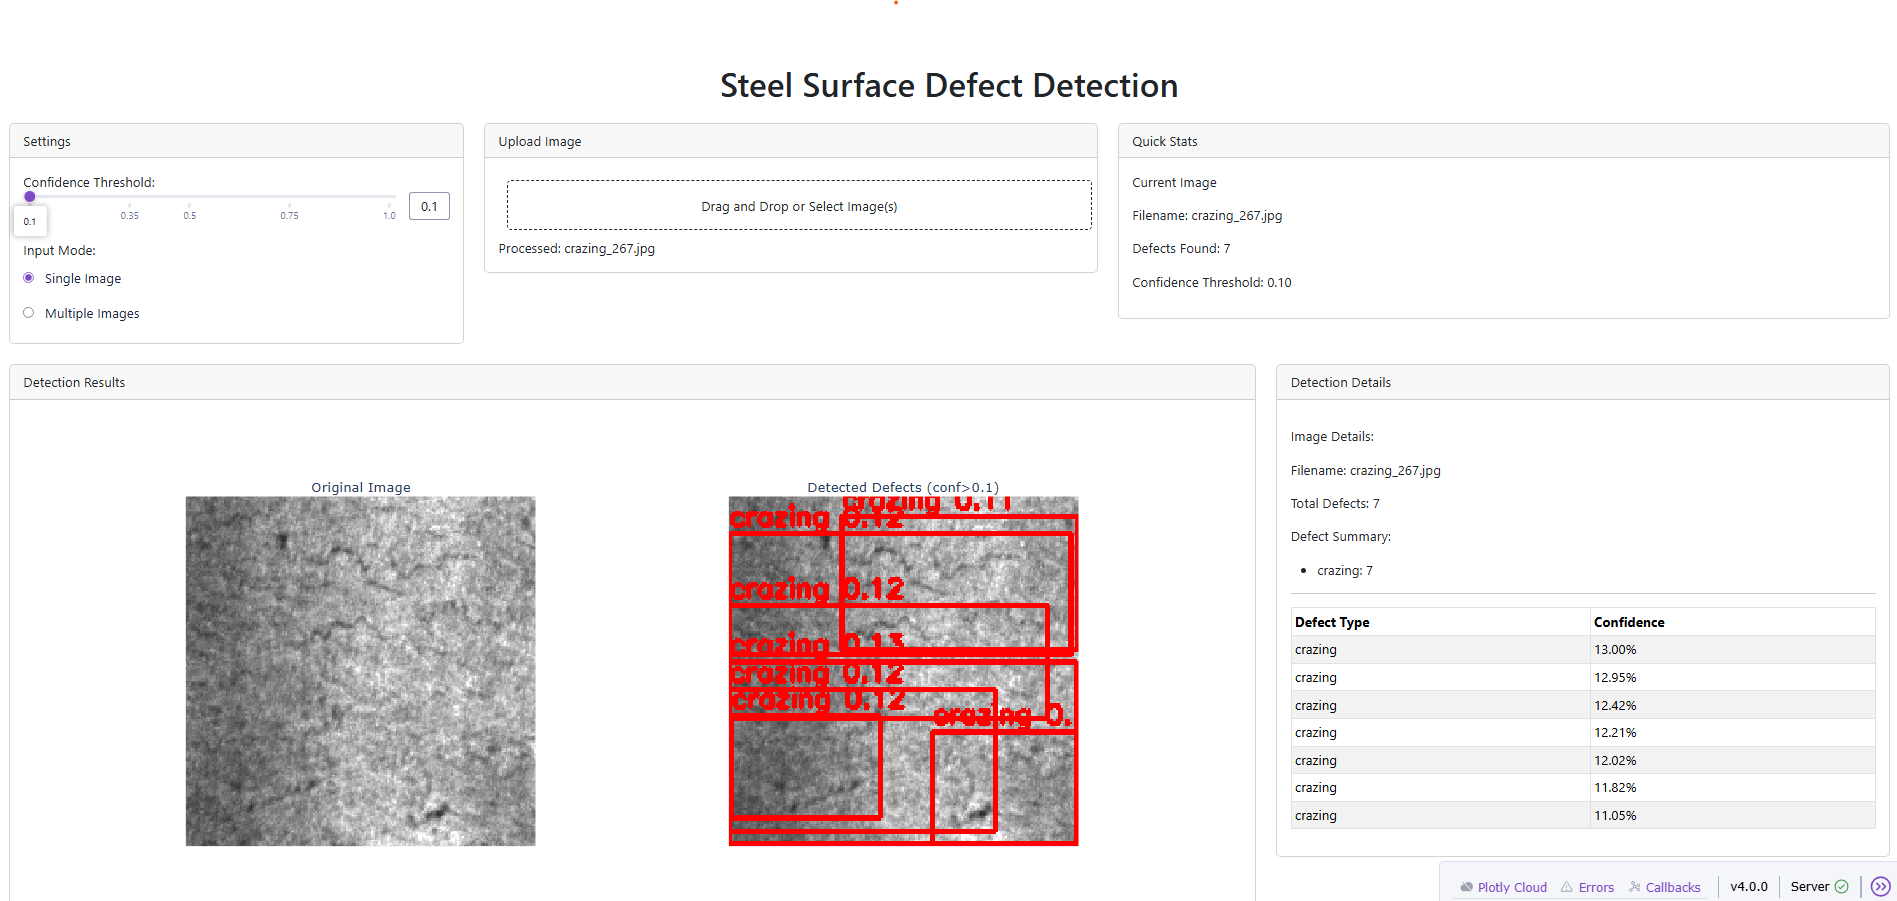